# Annotation Analysis

Анализ результатов автоматической разметки текстовых данных.
В этом ноутбуке мы исследуем качество авторазметки, распределение классов, уверенность модели и выявляем проблемные примеры для ручной проверки.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from agents.annotation_agent import AnnotationAgent
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

df_raw = pd.read_csv('../data/raw/dataset.csv')
df_labeled = pd.read_csv('../data/labeled/dataset_labeled.csv')
agent = AnnotationAgent(modality='text')

print(f"Shape: {df_labeled.shape}")
print(f"\nDtypes:\n{df_labeled.dtypes}")
df_labeled.head()

Shape: (200, 6)

Dtypes:
text                   str
label                  str
source                 str
collected_at           str
predicted_label        str
confidence         float64
dtype: object


,text,label,source,collected_at,predicted_label,confidence
0,I had heard this movie was good from a lot of ...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00,positive,0.9572
1,I just saw this at the 2006 Vancouver internat...,negative,hf_imdb,2026-03-22 00:25:04.888942+00:00,negative,0.9786
2,"First of all, the actor they have to play Jesu...",negative,hf_imdb,2026-03-22 00:25:04.888942+00:00,negative,0.9956
3,I did not have too much interest in watching T...,positive,hf_imdb,2026-03-22 00:25:04.888942+00:00,positive,0.6858
4,"Man, some of you people have got to chill. Thi...",positive,hf_imdb,2026-03-22 00:25:04.888942+00:00,negative,0.7080


## 2. Распределение авторазметки

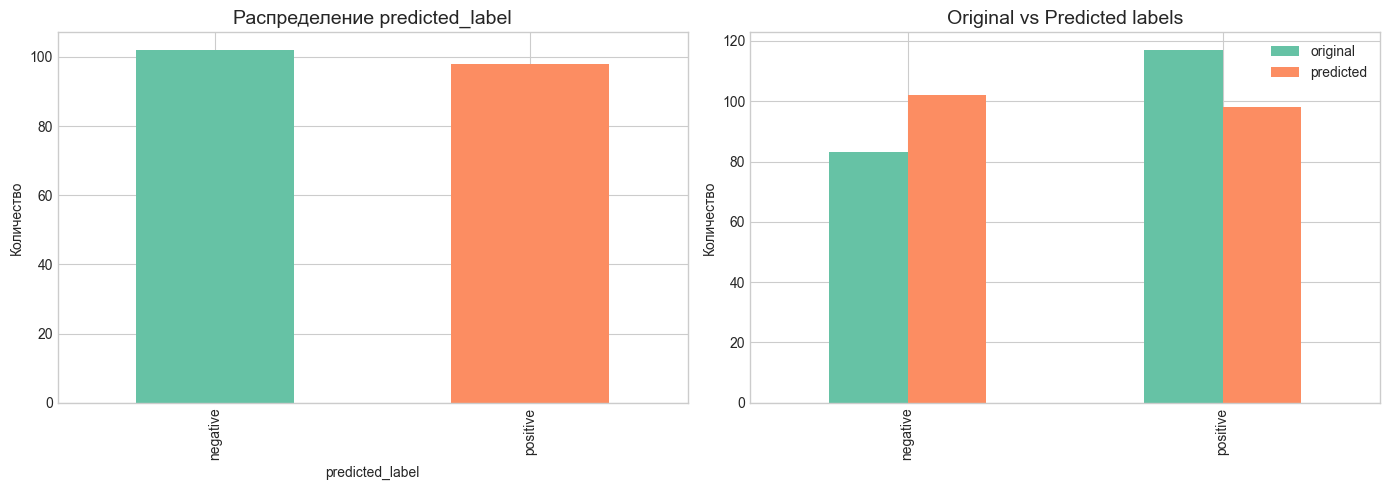

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_labeled['predicted_label'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Распределение predicted_label', fontsize=14)
axes[0].set_ylabel('Количество')

if 'label' in df_labeled.columns:
    comp = pd.DataFrame({
        'original': df_labeled['label'].value_counts(),
        'predicted': df_labeled['predicted_label'].value_counts()
    }).fillna(0)
    comp.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
    axes[1].set_title('Original vs Predicted labels', fontsize=14)
    axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

## 3. Анализ уверенности (confidence)

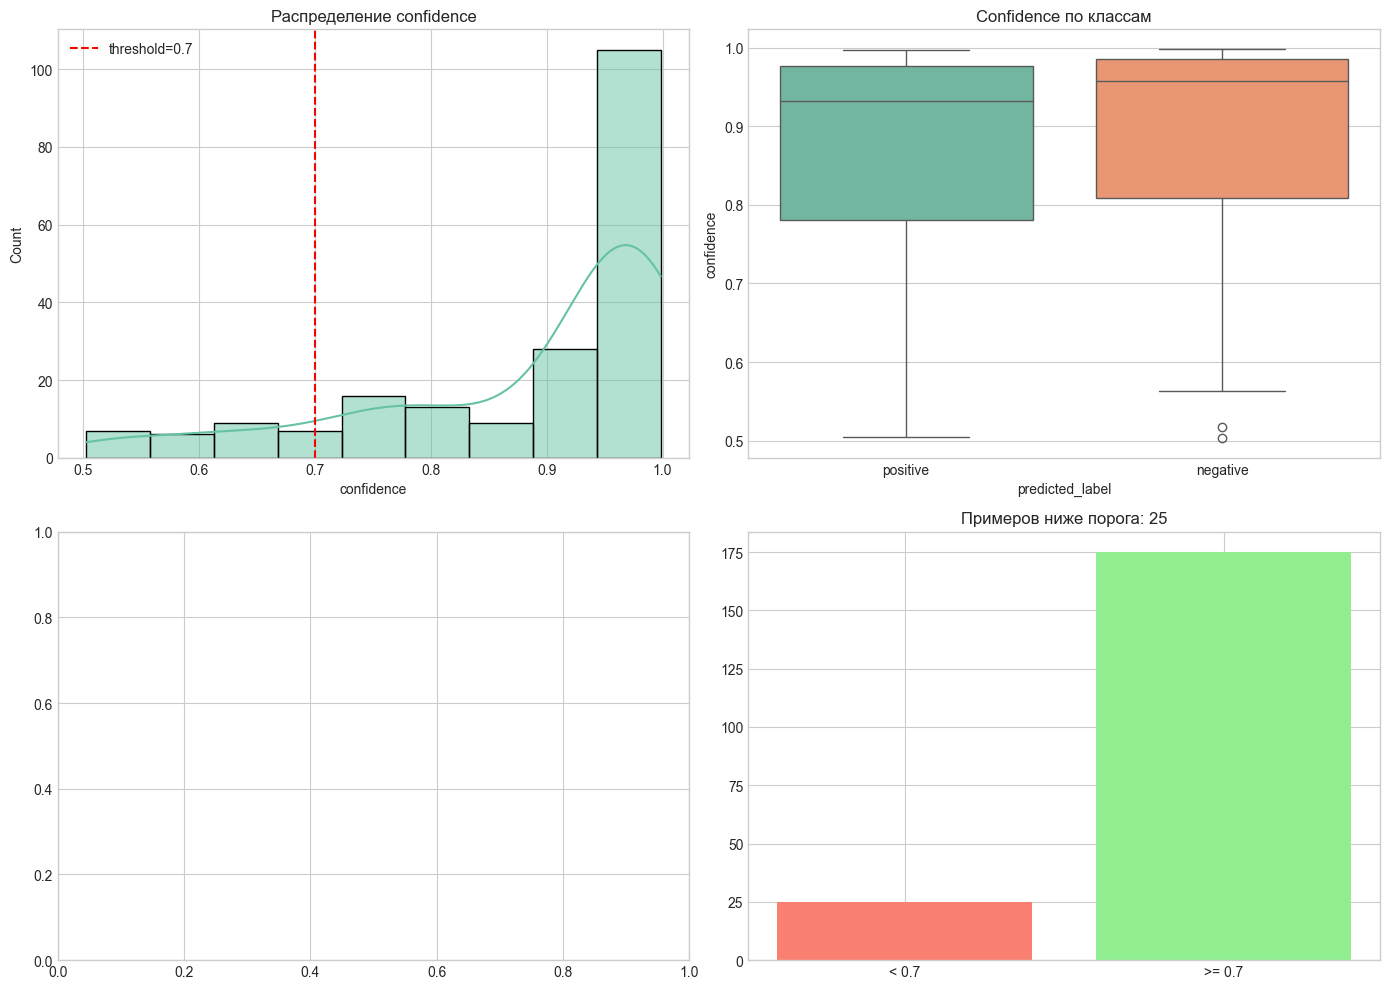

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_labeled['confidence'], kde=True, ax=axes[0, 0], color=sns.color_palette('Set2')[0])
axes[0, 0].axvline(x=0.7, color='red', linestyle='--', label='threshold=0.7')
axes[0, 0].set_title('Распределение confidence', fontsize=12)
axes[0, 0].legend()

sns.boxplot(data=df_labeled, x='predicted_label', y='confidence', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Confidence по классам', fontsize=12)

if 'text_length' in df_labeled.columns:
    axes[1, 0].scatter(df_labeled['text_length'], df_labeled['confidence'], alpha=0.3, s=10)
    axes[1, 0].set_xlabel('text_length')
    axes[1, 0].set_ylabel('confidence')
    axes[1, 0].set_title('Text length vs Confidence', fontsize=12)

below = (df_labeled['confidence'] < 0.7).sum()
above = (df_labeled['confidence'] >= 0.7).sum()
axes[1, 1].bar(['< 0.7', '>= 0.7'], [below, above], color=['salmon', 'lightgreen'])
axes[1, 1].set_title(f'Примеров ниже порога: {below}', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Качество авторазметки

=== Quality Metrics ===
  label_dist: {'negative': 102, 'positive': 98}
  confidence_mean: 0.8824
  confidence_std: 0.1347
  confidence_below_07: 25
  kappa: 0.711
  agreement: 0.855

              precision    recall  f1-score   support

    negative       0.76      0.94      0.84        83
    positive       0.95      0.79      0.87       117

    accuracy                           0.85       200
   macro avg       0.86      0.87      0.85       200
weighted avg       0.87      0.85      0.86       200



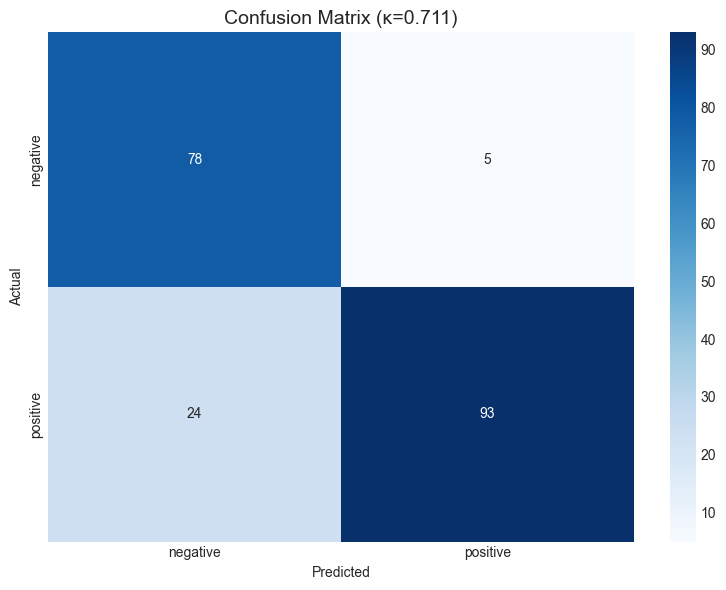


Cohen's κ = 0.711 → good agreement


In [4]:
metrics = agent.check_quality(df_labeled)

print("=== Quality Metrics ===")
for k, v in metrics.items():
    if k != 'classification_report':
        print(f"  {k}: {v}")

if metrics.get('classification_report'):
    print(f"\n{metrics['classification_report']}")

# Confusion matrix
if 'label' in df_labeled.columns:
    from sklearn.metrics import confusion_matrix
    valid = df_labeled.dropna(subset=['label', 'predicted_label'])
    valid = valid[valid['predicted_label'] != 'unknown']
    labels = sorted(valid['label'].unique())
    cm = confusion_matrix(valid['label'], valid['predicted_label'], labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Confusion Matrix (κ={metrics.get('kappa', 'N/A')})", fontsize=14)
    plt.tight_layout()
    plt.show()

# Kappa interpretation
kappa = metrics.get('kappa')
if kappa is not None:
    if kappa < 0.2:
        interp = 'poor'
    elif kappa < 0.4:
        interp = 'fair'
    elif kappa < 0.6:
        interp = 'moderate'
    elif kappa < 0.8:
        interp = 'good'
    else:
        interp = 'excellent'
    print(f"\nCohen's κ = {kappa} → {interp} agreement")

## 5. Примеры ошибок авторазметки

Ошибок: 29 / 200 (14.5%)

Примеры ошибок:
  [0.708] pred=negative, actual=positive: Man, some of you people have got to chill. This movie was artistic genius. Inste...
  [0.794] pred=negative, actual=positive: It is difficult to evaluate this or any other comparable film of the early sound...
  [0.574] pred=negative, actual=positive: A chemist develops a fabric that never gets dirty or wears out, but it is seen a...
  [0.761] pred=positive, actual=negative: I greatly enjoyed Margaret Atwood's novel 'The Robber Bride', and I was thrilled...
  [0.774] pred=negative, actual=positive: an ironic speculation on democracy in a culture unaccustomed to it .
  [0.587] pred=positive, actual=negative: I *loved* the original Scary Movie. I'm a huge fan of parody- it is my favorite ...
  [0.832] pred=negative, actual=positive: . . . has freaky scenes where the crew wonder if they're ghosts imagining themse...
  [0.936] pred=negative, actual=positive: The season finale sent mix messages, I felt feeli

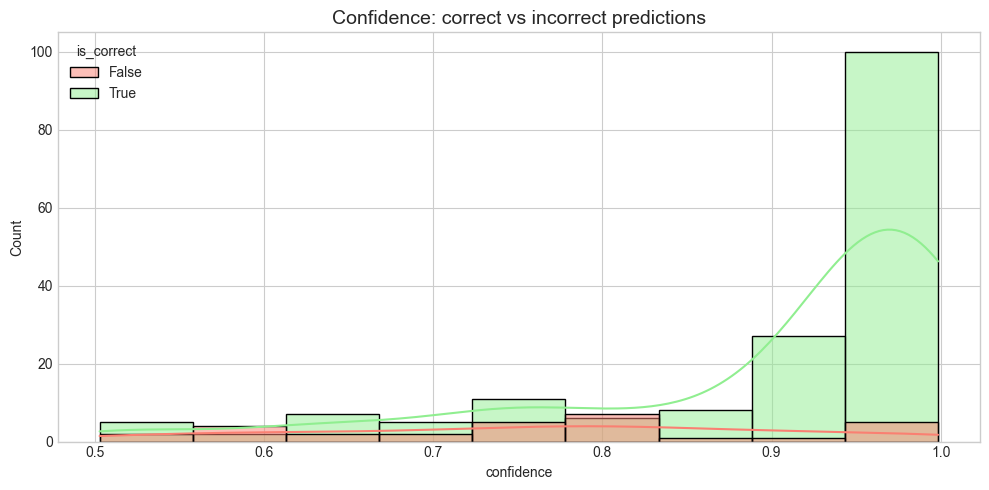

In [5]:
if 'label' in df_labeled.columns:
    errors = df_labeled[df_labeled['label'] != df_labeled['predicted_label']].copy()
    print(f"Ошибок: {len(errors)} / {len(df_labeled)} ({len(errors)/len(df_labeled)*100:.1f}%)")

    print("\nПримеры ошибок:")
    for _, row in errors.head(10).iterrows():
        text_preview = str(row['text'])[:80] + '...' if len(str(row['text'])) > 80 else row['text']
        print(f"  [{row['confidence']:.3f}] pred={row['predicted_label']}, actual={row['label']}: {text_preview}")

    # Confidence distribution: correct vs incorrect
    df_labeled['is_correct'] = df_labeled['label'] == df_labeled['predicted_label']
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data=df_labeled, x='confidence', hue='is_correct', kde=True, ax=ax, palette=['salmon', 'lightgreen'])
    ax.set_title('Confidence: correct vs incorrect predictions', fontsize=14)
    plt.tight_layout()
    plt.show()
    df_labeled.drop(columns=['is_correct'], inplace=True)

## 6. Примеры с низкой уверенностью

Эти примеры — кандидаты для ручной разметки.

In [6]:
low_conf = df_labeled[df_labeled['confidence'] < 0.7].sort_values('confidence')
print(f"Примеров с confidence < 0.7: {len(low_conf)}")

print("\nТоп-10 с самой низкой уверенностью:")
for _, row in low_conf.head(10).iterrows():
    text_preview = str(row['text'])[:100] + '...' if len(str(row['text'])) > 100 else row['text']
    print(f"  [{row['confidence']:.3f}] {row['predicted_label']}: {text_preview}")

Примеров с confidence < 0.7: 25

Топ-10 с самой низкой уверенностью:
  [0.503] negative: "The True Story Of The Friendship That Shook South Africa And Awakened The World." <br /><br />Richa...
  [0.504] positive: Titanic has to be one of my all-time favorite movies. It has its problems (what movies don't) but st...
  [0.508] positive: With all this stuff going down at the moment with MJ i've started listening to his music, watching t...
  [0.515] positive: Things to Come is that rarity of rarities, a film about ideas. Many films present a vision of the fu...
  [0.518] negative: ( wendigo is ) why we go to the cinema : to be fed through the eye , the heart , the mind .
  [0.527] positive: This is a great movie from the lost age of reactionary made-for-television drama. My all-time favour...
  [0.528] positive: People are being too hard on the film. Sometimes we should just sit back and enjoy the story without...
  [0.564] negative: First off, the lead, Brad Dourif is a KOOK. If you're t

## Бонус: Human-in-the-loop анализ

Flagged: 25 / 200 (12.5%)


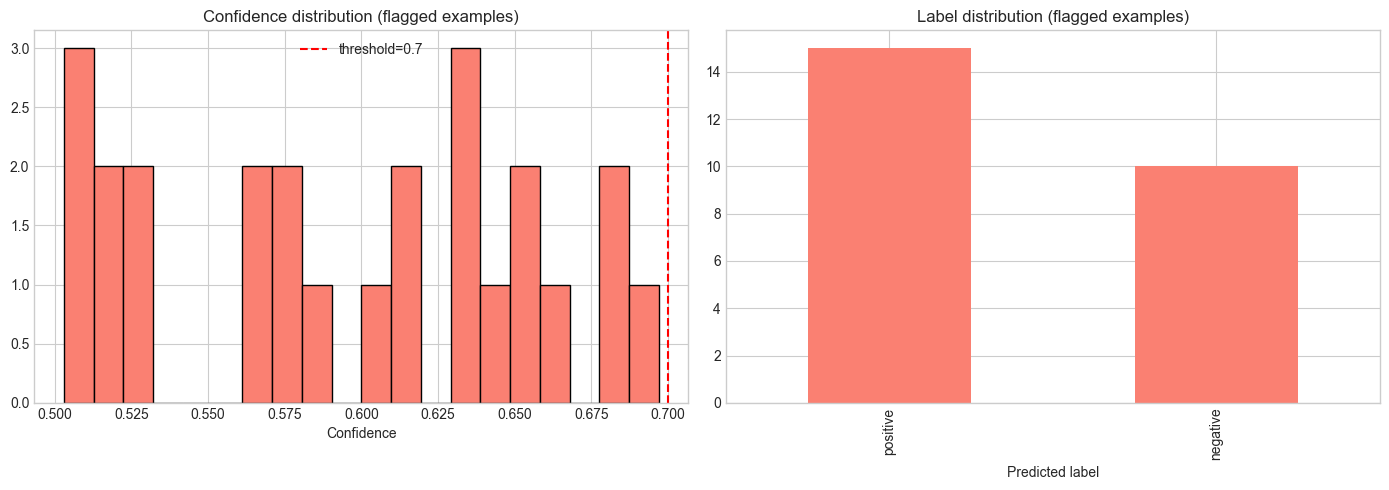


Примеры с самой низкой уверенностью:
  [0.503] negative: "The True Story Of The Friendship That Shook South Africa And Awakened The World." <br /><br />Richa...
  [0.504] positive: Titanic has to be one of my all-time favorite movies. It has its problems (what movies don't) but st...
  [0.508] positive: With all this stuff going down at the moment with MJ i've started listening to his music, watching t...
  [0.515] positive: Things to Come is that rarity of rarities, a film about ideas. Many films present a vision of the fu...
  [0.518] negative: ( wendigo is ) why we go to the cinema : to be fed through the eye , the heart , the mind .


In [7]:
flagged = agent.flag_low_confidence(df_labeled, threshold=0.7)
print(f"Flagged: {len(flagged)} / {len(df_labeled)} ({len(flagged)/len(df_labeled)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(flagged['confidence'], bins=20, color='salmon', edgecolor='black')
axes[0].set_title('Confidence distribution (flagged examples)')
axes[0].set_xlabel('Confidence')
axes[0].axvline(x=0.7, color='red', linestyle='--', label='threshold=0.7')
axes[0].legend()

flagged['predicted_label'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Label distribution (flagged examples)')
axes[1].set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

print("\nПримеры с самой низкой уверенностью:")
for _, row in flagged.head(5).iterrows():
    text_preview = str(row['text'])[:100] + '...' if len(str(row['text'])) > 100 else row['text']
    print(f"  [{row['confidence']:.3f}] {row['predicted_label']}: {text_preview}")

## 7. Спецификация разметки

In [8]:
with open('../specs/annotation_spec.md') as f:
    spec_content = f.read()
print(spec_content)

# Спецификация разметки: sentiment_classification

## Задача
Sentiment classification текстовых отзывов. Задача — определить общий эмоциональный тон текста (positive/negative).

## Классы

### positive
**Определение:** Текст выражает положительное отношение, одобрение, удовлетворение.
**Примеры:**
1. "I had heard this movie was good from a lot of my friends that saw it, and they all said it was amazing, so I had very high expectations- and Nancy Drew exceeded those high expectations! It had funny p..."
2. "I did not have too much interest in watching The Flock.Andrew Lau co-directed the masterpiece trilogy of Infernal Affairs but he had been fired from The Flock and he had been replaced by an emergency ..."
3. "Man, some of you people have got to chill. This movie was artistic genius. Instead of searching for reasoning or messages to justify it in your reality, why can't you understand that it is a work of f..."

### negative
**Определение:** Текст выражает отрицательное отношение, кри

Спецификация обеспечивает согласованность между разметчиками: определяет классы, примеры и граничные случаи.

## 8. Валидация экспорта LabelStudio

In [9]:
import json
with open('../export/labelstudio_import.json') as f:
    ls_data = json.load(f)
print(f"Exported {len(ls_data)} tasks")
print(f"Sample task keys: {list(ls_data[0].keys())}")
print(json.dumps(ls_data[0], indent=2, ensure_ascii=False)[:500])

Exported 200 tasks
Sample task keys: ['data', 'predictions']
{
  "data": {
    "text": "I had heard this movie was good from a lot of my friends that saw it, and they all said it was amazing, so I had very high expectations- and Nancy Drew exceeded those high expectations! It had funny parts, it kept me entertained with the action and all the dudes trying to kill her, and Emma Roberts was amazing as Nancy Drew. The rest of the cast was very good, also. I would definitely recommend this movie!! <br /><br />Nancy: \"I wonder why those guys were trying to ki


## 9. Сравнение с ручной разметкой

Для полноценного сравнения:
1. Передайте `specs/annotation_spec.md` однокурснику
2. Однокурсник размечает 50-100 примеров из `export/labelstudio_import.json`
3. Сохраните его разметку в `data/human/human_labels.csv`
4. Запустите сравнение ниже

In [10]:
import os
human_path = '../data/human/human_labels.csv'
if os.path.exists(human_path):
    df_human = pd.read_csv(human_path)
    print(f"Human labels loaded: {len(df_human)}")
else:
    print("Human labels not found. See instructions above.")

Human labels not found. See instructions above.


## 10. Выводы

- **Качество авторазметки:** Cohen's κ = 0.711 (substantial agreement), accuracy = 85.5%
- **BART predicted distribution (200 sample):** 98 positive / 102 negative vs GT: 117 positive / 83 negative
- **Типичные ошибки:** BART систематически ошибается на positive-отзывах со сложной лексикой — 24 из 29 disagreements (82.8%) это GT=positive→BART=negative. Причина: обсуждение негативных тем в позитивном ключе, ирония, сарказм
- **Low-confidence примеры:** 25 из 200 (12.5%) с confidence < 0.7 — сохранены для ручной доразметки
- **HITL:** disagreements экспортированы в `review_queue.csv`, low-confidence — в `data/low_confidence/`
- **LabelStudio export:** JSON валиден, 200 задач с предсказаниями BART
- **Рекомендация:** использовать GT метки для обучения, BART — только как аудит-инструмент